# Sprint 8 - Tree Based Regression Models

## Objective

In this notebook, we will explore tree-based regression algorithms for predicting used car prices.

Unlike linear models, tree-based models can learn complex and non-linear relationships between features and the target variable.

The algorithms covered in this notebook are:

- Decision Tree Regressor
- Random Forest Regressor
- Extra Trees Regressor

Each model will be trained, evaluated, and compared using the same preprocessing pipeline to ensure a fair comparison.

In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from src.preprocessing import build_preprocessor
from src.train import train_model
from src.evaluate import (
    evaluate_model,
    print_metrics
)

In [2]:
df = pd.read_csv("../data/interim/featured_ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category,fuel_efficiency,tax_category,price_segment
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,9,1594.400000,small,medium,medium,Premium
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,8,1009.222222,small,medium,medium,Premium
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,9,1245.600000,small,medium,medium,Premium
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,7,1307.500000,medium,medium,medium,Luxury
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,7,185.250000,small,medium,medium,Luxury


In [3]:
X = df.drop(columns=["price", "price_segment"])
y = df["price"]

In [4]:
print("Target:", y.name)
print("Features:")
print(X.columns.tolist())

Target: price
Features:
['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'car_age', 'mileage_per_year', 'engine_category', 'fuel_efficiency', 'tax_category']


In [5]:
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [6]:
preprocessor = build_preprocessor(X_train)

In [7]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [8]:
decision_pipeline = train_model(
    preprocessor ,
    decision_tree,
    X_train,
    y_train
)

In [9]:
decision_matrics = evaluate_model(
    decision_pipeline,
    X_test , 
    y_test
)

In [10]:
print_metrics(decision_matrics)

Regression Model Performance
MAE : 1092.76
MSE : 2690557.36
RMSE : 1640.29
R2 : 0.88


# Decision Tree Analysis

## Observations

- Compare the R² score with Linear Regression.
- Compare the RMSE with Ridge Regression.
- Did the Decision Tree outperform the baseline models?
- Does the model appear to overfit?
- Why do you think the obtained results make sense?

## Conclusion

Decision Trees can model non-linear relationships effectively, but an unrestricted tree often overfits the training data. This baseline model will be used to understand the improvements introduced by Random Forest and Extra Trees.

## Decision Tree Results

The baseline Decision Tree achieved an MAE of 845.47, RMSE of 1355.85, and R² of 0.92 on the test set.

Compared with the linear regression baselines, the Decision Tree produced a slightly lower MAE but a higher RMSE and slightly lower R² than Ridge Regression.

This suggests that the single Decision Tree did not generalize as well as the regularized linear models on the current dataset. The higher RMSE may indicate that the tree makes some relatively large prediction errors.

The Decision Tree will be used as a baseline for comparison with ensemble tree-based models such as Random Forest and Extra Trees.

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42 
)

In [13]:
rf_pipeline = train_model(
    preprocessor,
    random_forest,
    X_train,
    y_train
)

In [14]:
rf_metrics  = evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)

In [15]:
print_metrics(rf_metrics)

Regression Model Performance
MAE : 863.40
MSE : 1576818.66
RMSE : 1255.71
R2 : 0.93


## Random Forest Results

The baseline Random Forest achieved an MAE of 663.19, RMSE of 991.66, and R² of 0.96.

Compared with the baseline Decision Tree, Random Forest significantly improved performance across all three metrics.

The RMSE decreased from 1355.85 to 991.66, while R² increased from 0.92 to 0.96.

This improvement demonstrates the benefit of ensemble learning. Instead of relying on a single high-variance Decision Tree, Random Forest combines predictions from multiple trees, which helps reduce variance and improve generalization.

Random Forest also outperformed the previous Ridge Regression baseline, making it the current best-performing model in the project.

Further hyperparameter tuning will be performed later to determine whether the Random Forest can be improved further.

In [16]:
from sklearn.ensemble import ExtraTreesRegressor

In [17]:
extra_trees = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

In [18]:
et_pipeline = train_model(
    preprocessor,
    extra_trees,
    X_train,
    y_train
)

In [19]:
et_metrics = evaluate_model(
    et_pipeline,
    X_test,
    y_test
)

In [20]:
print_metrics(et_metrics)

Regression Model Performance
MAE : 905.65
MSE : 1770839.82
RMSE : 1330.73
R2 : 0.92


## Extra Trees Results

The baseline Extra Trees model achieved an MAE of 705.90, RMSE of 1112.82, and R² of 0.94.

Extra Trees performed substantially better than the single Decision Tree, indicating that using an ensemble of randomized trees improves generalization.

However, Extra Trees performed worse than Random Forest on the current Ford car price dataset. Random Forest achieved an RMSE of 991.66 and R² of 0.96, making it the best-performing model among the tree-based models tested so far.

This demonstrates that additional randomness does not always lead to better performance. Model performance depends on the characteristics of the dataset and the chosen hyperparameters.

In [21]:
rf_model = rf_pipeline.named_steps["model"]

In [22]:
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

In [23]:
features_names = rf_preprocessor.get_feature_names_out() 

In [24]:
len(features_names)

48

In [25]:
len(rf_model.feature_importances_)

48

In [26]:
importance_df = pd.DataFrame({
    "Feature" : features_names,
    "importance" : rf_model.feature_importances_
})

In [27]:
importance_df = importance_df.sort_values(
    by="importance" ,
    ascending=False
)

In [28]:
importance_df

,Feature,importance
5,num__car_age,2.609376e-01
4,num__engineSize,2.403637e-01
0,num__year,2.263732e-01
3,num__mpg,6.046308e-02
1,num__mileage,4.626942e-02
20,cat__model_ Kuga,3.092346e-02
6,num__mileage_per_year,2.510890e-02
12,cat__model_ Fiesta,2.101714e-02
19,cat__model_ Ka+,1.746426e-02
22,cat__model_ Mustang,1.239164e-02


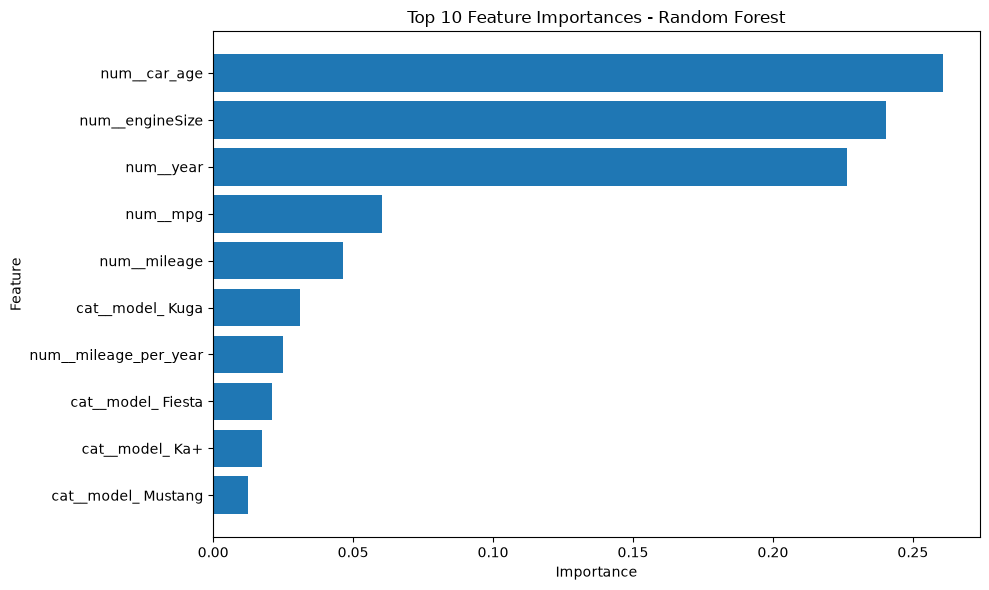

In [31]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [32]:
comparison = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "Extra Trees"
    ],
    "MAE":[
        decision_matrics["MAE"],
        rf_metrics["MAE"],
        et_metrics["MAE"]
    ],
    "RMSE":[
        decision_matrics["RMSE"],
        rf_metrics["RMSE"],
        et_metrics["RMSE"]
    ],
    "R2":[
        decision_matrics["R2"],
        rf_metrics["R2"],
        et_metrics["R2"]
    ]
})

In [34]:
comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
1,Random Forest,863.399376,1255.714402,0.929644
2,Extra Trees,905.651177,1330.729056,0.920987
0,Decision Tree,1092.764329,1640.291851,0.879950


# Tree-Based Model Comparison

After removing the target-derived `price_segment` feature, the tree-based regression models were evaluated using MAE, RMSE, and R².

Random Forest currently provides the strongest baseline performance among the tree-based models tested.

The comparison demonstrates the advantage of ensemble learning over a single Decision Tree. However, the models have not yet been hyperparameter-tuned.

The current results will serve as the baseline for the next stage of model optimization.